# Dataset: Diabetes Health Indicators

For this classification task I will be using this [Diabetes Health Indicator Dataset](https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset) from Kaggle.<br>
This synthetic dataset includes features about people's demographics, lifestyle habits, family history, and clinical measurements. <br>
The file `diabetes_dataset.csv` contains these feature columns and an column indicating whether or not each person was diagnosed with diabetes.

# Objective

I will be attempting to predict the diabetes diagnosis of members of the sample population using the features included in this dataset.<br>
More specifically, the `diagnosed_diabetes` column will be the target variable for this section.

In [133]:
import pandas as pd
import numpy as np

In [134]:
df_dhi = pd.read_csv("diabetes_dataset.csv");

In [135]:
df_dhi.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

# Data Preprocessing

The dataset has had some preprocessing beforehand. <br> 
There are no missing or unrealistic values. <br>
However, data type conversion and normalization are still required.

In [136]:
# Confirm no values are missing
print(f"Any missing values: {np.any(df_dhi.isna().sum())}")

Any missing values: False


In [137]:
# Drop these columns since they are diagnostic indicators and would trivialize the task
df_dhi = df_dhi.drop(columns=["diabetes_stage", "diabetes_risk_score", "hba1c"])

In [138]:
# Convert categories to numerical indicators
df_dhi = pd.get_dummies(df_dhi, dtype="float", drop_first=True)

In [139]:
from sklearn.preprocessing import MinMaxScaler

# Ensure target is not affected by feature normalization
diagnosed = df_dhi["diagnosed_diabetes"]
df_dhi = df_dhi.drop(columns=["diagnosed_diabetes"])

# Normalize features
mms_dhi = MinMaxScaler()
scaled_features = mms_dhi.fit_transform(df_dhi)
df_dhi = pd.DataFrame(scaled_features, columns=df_dhi.columns)

## Target Variable Characteristics

In [140]:
diagnosed.value_counts(normalize=True)

diagnosed_diabetes
1    0.59998
0    0.40002
Name: proportion, dtype: float64

# Model Implementation

In [141]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, roc_curve, roc_auc_score
from matplotlib import pyplot as plt

In [142]:
X = df_dhi
y = diagnosed

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Logistic Regression

In [144]:
from sklearn.linear_model import LogisticRegression

In [145]:
param_grid = {
    'C':            [0.1, 1, 10],
    'l1_ratio':     [0, 0.5, 1],
    'fit_intercept':[True, False],
}

search = GridSearchCV(LogisticRegression(solver="saga"), param_grid, cv=5, scoring='f1', n_jobs=-1)
search.fit(X_train, y_train);

In [146]:
lr_model = search.best_estimator_
y_pred_train = lr_model.predict(X_train)
y_score_train = lr_model.predict_proba(X_train)[:,1]

y_pred_test = lr_model.predict(X_test)
y_score_test = lr_model.predict_proba(X_test)[:,1]

In [147]:
f1_train = f1_score(y_train, y_pred_train)
print(f"Training F1 Score: {f1_train}")

f1_test = f1_score(y_test, y_pred_test)
print(f"Test F1 Score    : {f1_test}")

Training F1 Score: 0.8639318485836991
Test F1 Score    : 0.8645136632906555


Training ROC AUC: 0.9120386068427981
Test ROC AUC    : 0.9118206367989251


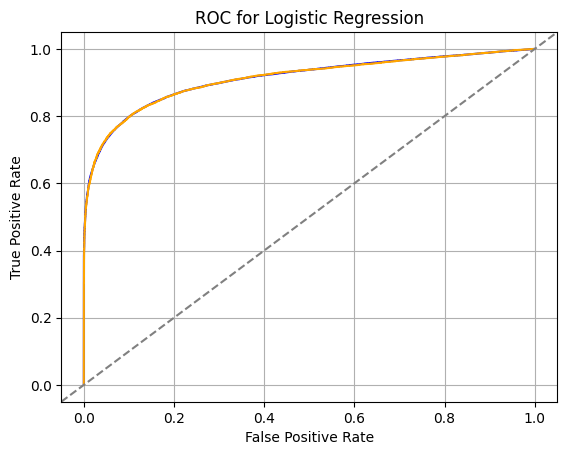

In [148]:
roc_train_fpr, roc_train_tpr, roc_train_threshold = roc_curve(y_train, y_score_train)
auc_train = roc_auc_score(y_train, y_score_train)
print(f"Training ROC AUC: {auc_train}")

roc_test_fpr, roc_test_tpr, roc_test_thresholds = roc_curve(y_test, y_score_test)
auc_test = roc_auc_score(y_test, y_score_test)
print(f"Test ROC AUC    : {auc_test}")

plt_bounds = [-0.05, 1.05]
plt.plot(roc_train_fpr, roc_train_tpr, color="blue");
plt.plot(roc_test_fpr, roc_test_tpr, color="orange");
plt.plot(plt_bounds, plt_bounds, color="grey", linestyle="--")
plt.xlim(plt_bounds)
plt.ylim(plt_bounds)
plt.grid(True)
plt.title("ROC for Logistic Regression");
plt.xlabel("False Positive Rate");
plt.ylabel("True Positive Rate");

## Multilayer Perceptron

In [149]:
from sklearn.neural_network import MLPClassifier

In [150]:
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 64), (128, 128)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
}

search = GridSearchCV(MLPClassifier(early_stopping=True), param_grid, cv=5, scoring='f1', n_jobs=-1)
search.fit(X_train, y_train);

In [151]:
mlp_model = search.best_estimator_
y_pred_train = mlp_model.predict(X_train)
y_score_train = mlp_model.predict_proba(X_train)[:,1]

y_pred_test = mlp_model.predict(X_test)
y_score_test = mlp_model.predict_proba(X_test)[:,1]

In [152]:
f1_train = f1_score(y_train, y_pred_train)
print(f"Training F1 Score: {f1_train}")

f1_test = f1_score(y_test, y_pred_test)
print(f"Test F1 Score    : {f1_test}")

Training F1 Score: 0.8654779233381853
Test F1 Score    : 0.8644507042253521


Training ROC AUC: 0.9117031626545838
Test ROC AUC    : 0.9111250665780499


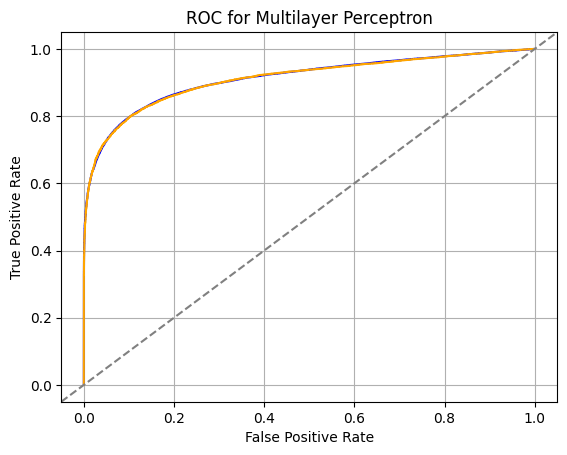

In [153]:
roc_train_fpr, roc_train_tpr, roc_train_threshold = roc_curve(y_train, y_score_train)
auc_train = roc_auc_score(y_train, y_score_train)
print(f"Training ROC AUC: {auc_train}")

roc_test_fpr, roc_test_tpr, roc_test_thresholds = roc_curve(y_test, y_score_test)
auc_test = roc_auc_score(y_test, y_score_test)
print(f"Test ROC AUC    : {auc_test}")

plt_bounds = [-0.05, 1.05]
plt.plot(roc_train_fpr, roc_train_tpr, color="blue");
plt.plot(roc_test_fpr, roc_test_tpr, color="orange");
plt.plot(plt_bounds, plt_bounds, color="grey", linestyle="--")
plt.xlim(plt_bounds)
plt.ylim(plt_bounds)
plt.grid(True)
plt.title("ROC for Multilayer Perceptron");
plt.xlabel("False Positive Rate");
plt.ylabel("True Positive Rate");

# Discussion

Both models performed quite well on this classification task. <br>
Both models yeilded a test F1 score of `~0.86` and a test AUC of `~0.91` which indicates that the models were able to learn a pattern in the dataset that was much more accurate than random guessing. <br>
The similarity of the results produced by the two models suggests that the relationship between the selected features and diabetes diagnosis may be approximately linear and there is no need for more complicated non-linear models like the neural network. <br>
Since the dataset is synthetic, this strong predictive performance is not particularly surprising.<br> 
It would be interesting to see how the performance of these models hold up on a real dataset.